# Deep Learning

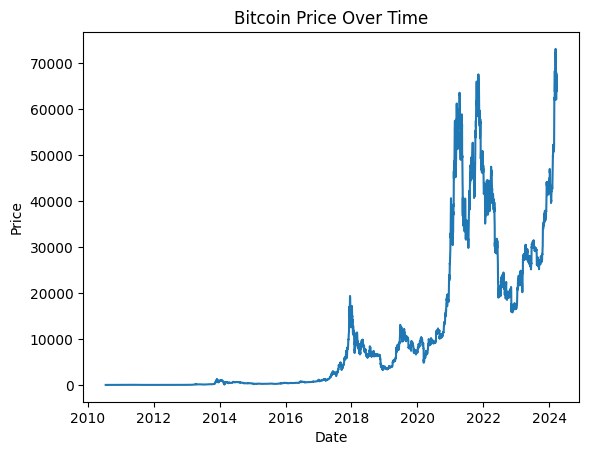

Date
2010-07-18    0.1
2010-07-19    0.1
2010-07-20    0.1
2010-07-21    0.1
2010-07-22    0.1
Name: Price, dtype: float64 Date
2024-03-20    67854.0
2024-03-21    65503.8
2024-03-22    63785.5
2024-03-23    64037.8
2024-03-24    67211.9
Name: Price, dtype: float64


In [404]:
import pandas as pd
from matplotlib import pyplot as plt

# Leer el archivo y procesar los datos
df = pd.read_csv("C:/Users/FBA/OneDrive - Acesco/0. Personales/2. Profesional/20240416 - Maestria en Analítica de Datos/20240919 Series de Tiempo/Parcial/bitcoin.txt", delimiter=',')

# Convertir 'Price' a numérico eliminando comas
df['Price'] = df['Price'].str.replace(',', '')
df['Price'] = pd.to_numeric(df['Price'])

# Convertir 'Date' a formato datetime y establecer como índice
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Ordenar el DataFrame por fecha
df = df.sort_values(by='Date', ascending=True)

# Graficar los precios
plt.plot(df.index, df['Price'])
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Bitcoin Price Over Time')
plt.show()

# Copiar la columna 'Price' a una nueva variable
df_price = df['Price'].copy()

# Mostrar las primeras filas de df_price
print(df_price.head(),df_price.tail())



In [436]:
import numpy as np
import pandas as pd

# Función para crear las ventanas deslizantes y asegurar que siempre existan valores para los `tau` futuros
def create_sliding_windows(data, window_sizes, step_size, taus):
    result_dict = {}  # Diccionario para almacenar los DataFrames por `window_size`

    for w in window_sizes:    
        all_combined_dfs = []  # Para almacenar resultados combinados para el tamaño de ventana actual

        for t in taus:
            X, y = [], []
            for i in range(0, len(data) - (w + t), step_size):
                X.append(data[i:i + w])  # Ventana de entrada
                
                # Agregar `Tau_0` como el valor justo después de la ventana
                tau_0_value = [data[i+w+t-1]] 
                
                # Obtener valores futuros para `tau`
                future_values = [data[i + w + j] for j in range(1, t + 1)]  # Valores futuros `tau` periodos por delante
                
                # Combinar `Tau_0` con los valores futuros
                y.append(tau_0_value)

            # Crear DataFrames
            df_X = pd.DataFrame(X)
            df_y = pd.DataFrame(y, columns=[f'Tau_{t}'])
            
            # Combinar DataFrames de la ventana y la salida de `tau`
            df_combined = pd.concat([df_X, df_y], axis=1)
            all_combined_dfs.append(df_combined)
        
        # Combinar todos los resultados en un solo DataFrame para el `window_size` actual
        final_df = pd.concat(all_combined_dfs, axis=0).reset_index(drop=True)
        
        # Guardar en el diccionario
        result_dict[f'Window_{w}'] = final_df
    
    return result_dict

  



In [455]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_ts(data, label_data, s_date, e_date, tau,w):
    df = pd.DataFrame(data).apply(pd.to_datetime)
    df_labels = pd.DataFrame(label_data)

    start_date = pd.to_datetime(s_date)
    end_date = pd.to_datetime(e_date)

    # Seleccionar columnas específicas para cambiar el color (ej. cambiar color de la columna 3 y 5)
    highlight_columns = tau

    # Filtrar las filas que contienen al menos una fecha dentro del rango
    filtered_indices = []
    for index, row in df.iterrows():
        if any((date >= start_date and date <= end_date) for date in row):
            filtered_indices.append(index)

    # Crear la figura
    plt.figure(figsize=(12, 8))

    # Definir colores en bloques de 14, 7, 7 (azul, naranja, verde)
    colors = ['blue']*2*w + ['orange'] *w + ['green'] *w
    color_cycle = len(colors)

    # Graficar solo las filas filtradas y agregar etiquetas a cada punto basadas en df_labels
    for index in filtered_indices:
        row_dates = df.iloc[index]
        row_labels = df_labels.iloc[index]
        
        # Determinar el color basado en el índice y la secuencia de colores
        block_index = index % color_cycle
        
        # Marcar los puntos para cada fecha dentro del rango seleccionado en el eje X
        for col, (date, label) in enumerate(zip(row_dates, row_labels)):
            if start_date <= date <= end_date:
                # Cambiar color si la columna está en highlight_columns
                color = 'red' if col in highlight_columns else colors[block_index]
                plt.plot(date, index, 'o', color=color)
                # Agregar etiqueta usando los valores de df_labels
                plt.text(date, index + 0.1, f'{label}', fontsize=8, ha='center')

    # Configurar etiquetas de los ejes
    plt.xlabel("Fechas")
    plt.ylabel("Índice")
    plt.title("Gráfico de fechas vs índice con etiquetas personalizadas y colores destacados")

    # Limitar el rango del eje X
    plt.xlim(start_date, end_date)

    # Limitar el rango del eje Y solo a los índices seleccionados
    plt.ylim(min(filtered_indices) - 1, max(filtered_indices) + 1)

    # Rotar las fechas para mejor visibilidad
    plt.gcf().autofmt_xdate()
    return plt.show()


In [407]:
# Función para segmentar los datos en train, validation y test
def segment_data_by_window(df, train_size, val_size, test_size):
    train_data, val_data, test_data = [], [], []
    
    i = 0
    while i + train_size + val_size + test_size <= len(df):
        # Segmento de entrenamiento
        train_data.append(df.iloc[i:i + train_size])
        # Segmento de validación
        val_data.append(df.iloc[i + train_size:i + train_size + val_size])
        # Segmento de prueba
        test_data.append(df.iloc[i + train_size + val_size:i + train_size + val_size + test_size])
        
        # Mover el índice al siguiente bloque
        i += train_size + val_size + test_size
    
    # Concatenar los segmentos de datos
    train_data = pd.concat(train_data).reset_index(drop=True)
    val_data = pd.concat(val_data).reset_index(drop=True)
    test_data = pd.concat(test_data).reset_index(drop=True)
    
    return train_data, val_data, test_data


In [417]:
# Ejemplo de uso:
window_sizes = [7, 14, 21, 28]
step_size = 1
taus = [0]  # Consideramos valores hasta `tau` de 28 periodos adelante

# Crear las ventanas deslizantes
result_dict = create_sliding_windows(df_price.index, window_sizes, step_size, taus)
result_dict2 = create_sliding_windows(df_price.values, window_sizes, step_size, taus)
# Definir tamaños para cada segmentación
segment_sizes = {
    7: (14, 7, 7),
    14: (28, 14, 14),
    21: (42, 21, 21),
    28: (56, 28, 28)
}

# Aplicar la segmentación a cada DataFrame
segmented_data = {}

for window_key, df in result_dict.items():
    window_size = int(window_key.split('_')[1])
    train_size, val_size, test_size = segment_sizes[window_size]
    
    # Obtener los datos segmentados
    train_data, val_data, test_data = segment_data_by_window(df, train_size, val_size, test_size)
    
    # Guardar en el diccionario
    segmented_data[window_key] = {
        'train': train_data,
        'validation': val_data,
        'test': test_data
    }

# Ejemplo de cómo acceder a los datos segmentados
print("Train Data for Window_7:")
print(segmented_data['Window_7']['train'])
print("Validation Data for Window_7:")
print(segmented_data['Window_7']['validation'])
print("Test Data for Window_7:")
print(segmented_data['Window_7']['test'])

# Aplicar la segmentación a cada DataFrame
segmented_data2 = {}

for window_key, df in result_dict2.items():
    window_size = int(window_key.split('_')[1])
    train_size, val_size, test_size = segment_sizes[window_size]
    
    # Obtener los datos segmentados
    train_data, val_data, test_data = segment_data_by_window(df, train_size, val_size, test_size)
    
    # Guardar en el diccionario
    segmented_data2[window_key] = {
        'train': train_data,
        'validation': val_data,
        'test': test_data
    }

# Ejemplo de cómo acceder a los datos segmentados
print("Train Data for Window_7:")
print(segmented_data2['Window_7']['train'])
print("Validation Data for Window_7:")
print(segmented_data2['Window_7']['validation'])
print("Test Data for Window_7:")
print(segmented_data2['Window_7']['test'])



Train Data for Window_7:
              0          1          2          3          4          5  \
0    2010-07-18 2010-07-19 2010-07-20 2010-07-21 2010-07-22 2010-07-23   
1    2010-07-19 2010-07-20 2010-07-21 2010-07-22 2010-07-23 2010-07-24   
2    2010-07-20 2010-07-21 2010-07-22 2010-07-23 2010-07-24 2010-07-25   
3    2010-07-21 2010-07-22 2010-07-23 2010-07-24 2010-07-25 2010-07-26   
4    2010-07-22 2010-07-23 2010-07-24 2010-07-25 2010-07-26 2010-07-27   
...         ...        ...        ...        ...        ...        ...   
2487 2024-02-20 2024-02-21 2024-02-22 2024-02-23 2024-02-24 2024-02-25   
2488 2024-02-21 2024-02-22 2024-02-23 2024-02-24 2024-02-25 2024-02-26   
2489 2024-02-22 2024-02-23 2024-02-24 2024-02-25 2024-02-26 2024-02-27   
2490 2024-02-23 2024-02-24 2024-02-25 2024-02-26 2024-02-27 2024-02-28   
2491 2024-02-24 2024-02-25 2024-02-26 2024-02-27 2024-02-28 2024-02-29   

              6      Tau_0  
0    2010-07-24 2010-07-25  
1    2010-07-25 2010-07-26  

7


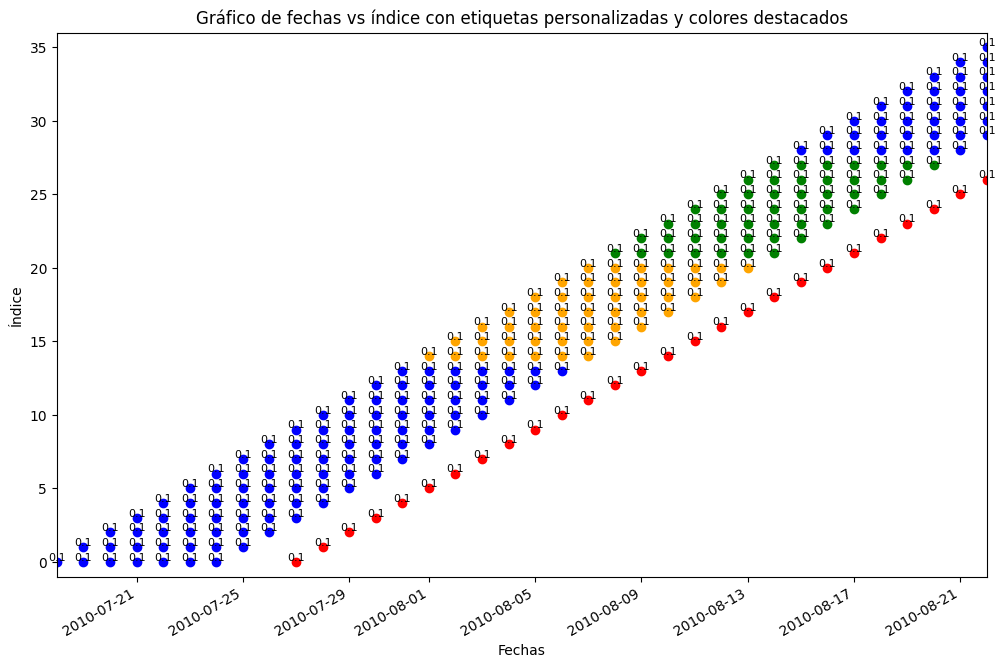

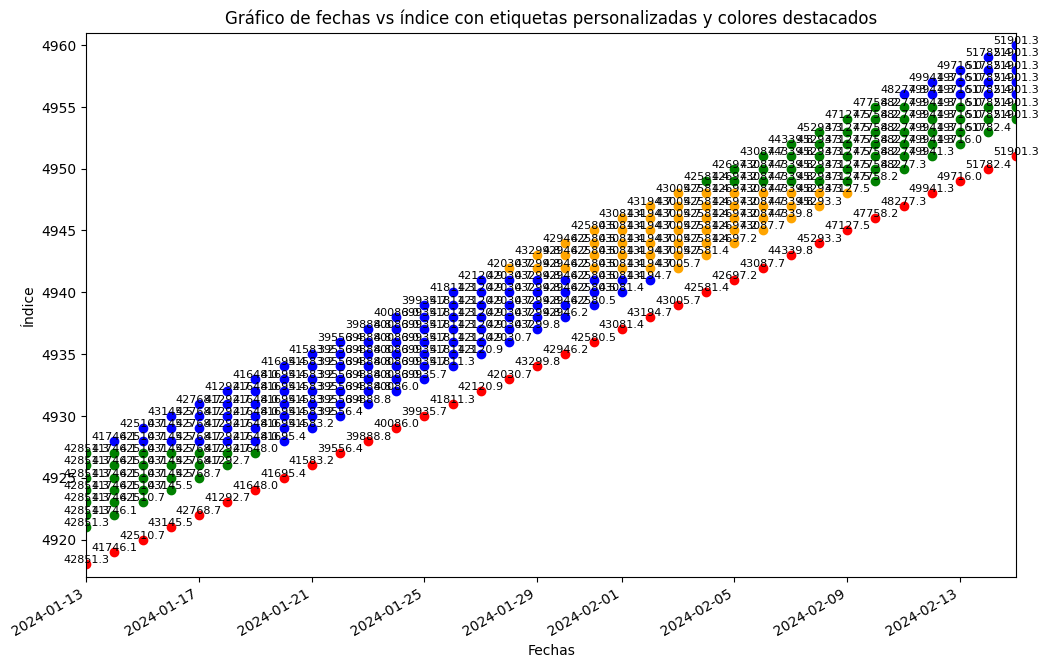


Window_7:
            0          1          2          3          4          5  \
0 2010-07-18 2010-07-19 2010-07-20 2010-07-21 2010-07-22 2010-07-23   
1 2010-07-19 2010-07-20 2010-07-21 2010-07-22 2010-07-23 2010-07-24   
2 2010-07-20 2010-07-21 2010-07-22 2010-07-23 2010-07-24 2010-07-25   
3 2010-07-21 2010-07-22 2010-07-23 2010-07-24 2010-07-25 2010-07-26   
4 2010-07-22 2010-07-23 2010-07-24 2010-07-25 2010-07-26 2010-07-27   

           6      Tau_3  
0 2010-07-24 2010-07-27  
1 2010-07-25 2010-07-28  
2 2010-07-26 2010-07-29  
3 2010-07-27 2010-07-30  
4 2010-07-28 2010-07-31  
14


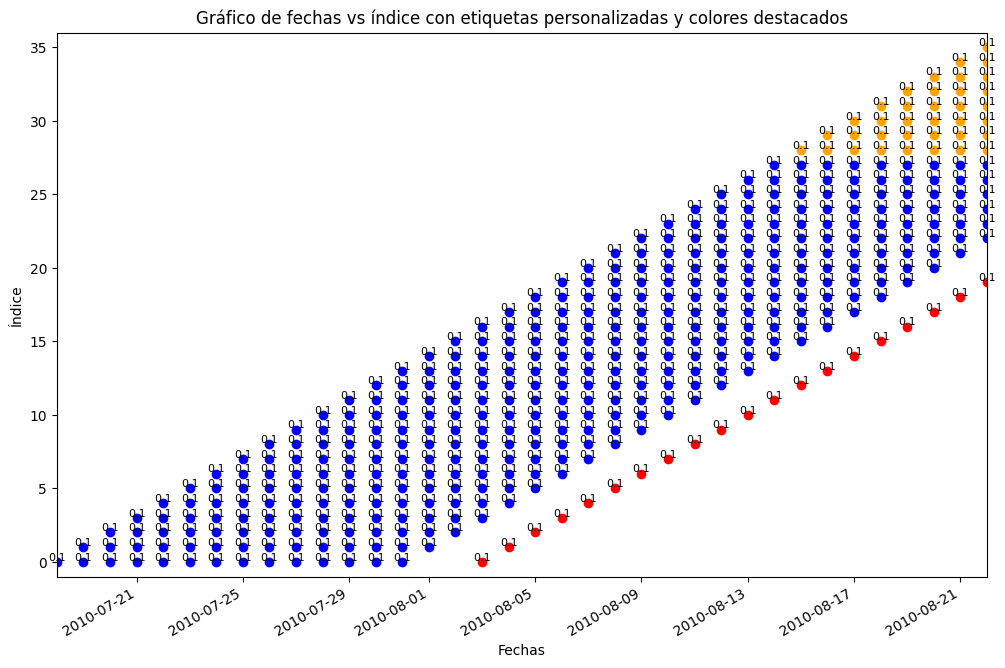

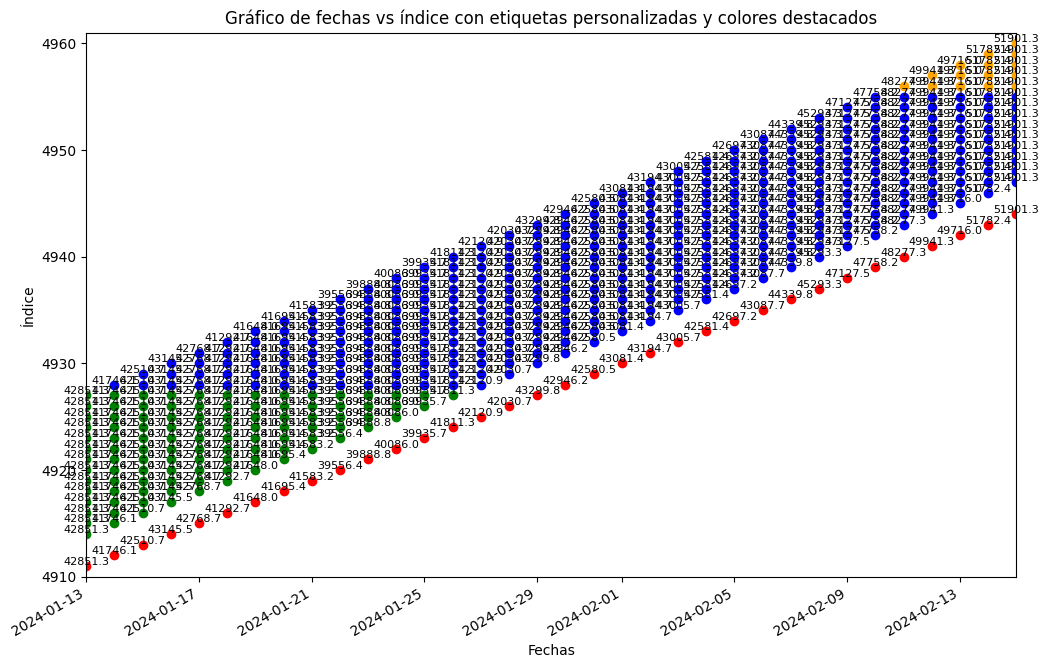


Window_14:
            0          1          2          3          4          5  \
0 2010-07-18 2010-07-19 2010-07-20 2010-07-21 2010-07-22 2010-07-23   
1 2010-07-19 2010-07-20 2010-07-21 2010-07-22 2010-07-23 2010-07-24   
2 2010-07-20 2010-07-21 2010-07-22 2010-07-23 2010-07-24 2010-07-25   
3 2010-07-21 2010-07-22 2010-07-23 2010-07-24 2010-07-25 2010-07-26   
4 2010-07-22 2010-07-23 2010-07-24 2010-07-25 2010-07-26 2010-07-27   

           6          7          8          9         10         11  \
0 2010-07-24 2010-07-25 2010-07-26 2010-07-27 2010-07-28 2010-07-29   
1 2010-07-25 2010-07-26 2010-07-27 2010-07-28 2010-07-29 2010-07-30   
2 2010-07-26 2010-07-27 2010-07-28 2010-07-29 2010-07-30 2010-07-31   
3 2010-07-27 2010-07-28 2010-07-29 2010-07-30 2010-07-31 2010-08-01   
4 2010-07-28 2010-07-29 2010-07-30 2010-07-31 2010-08-01 2010-08-02   

          12         13      Tau_3  
0 2010-07-30 2010-07-31 2010-08-03  
1 2010-07-31 2010-08-01 2010-08-04  
2 2010-08-01 2010-08-0

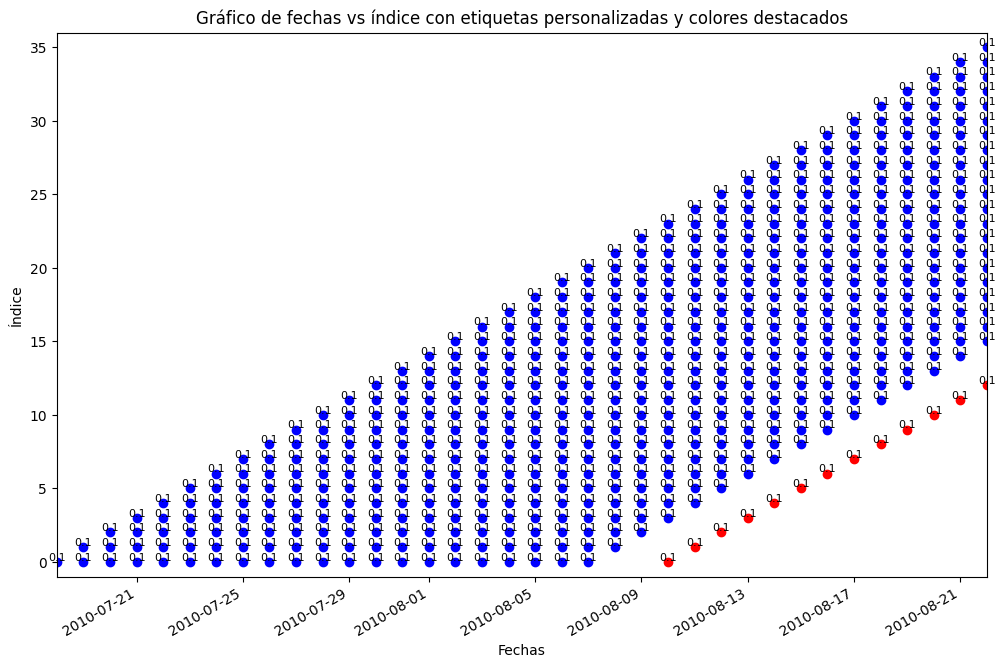

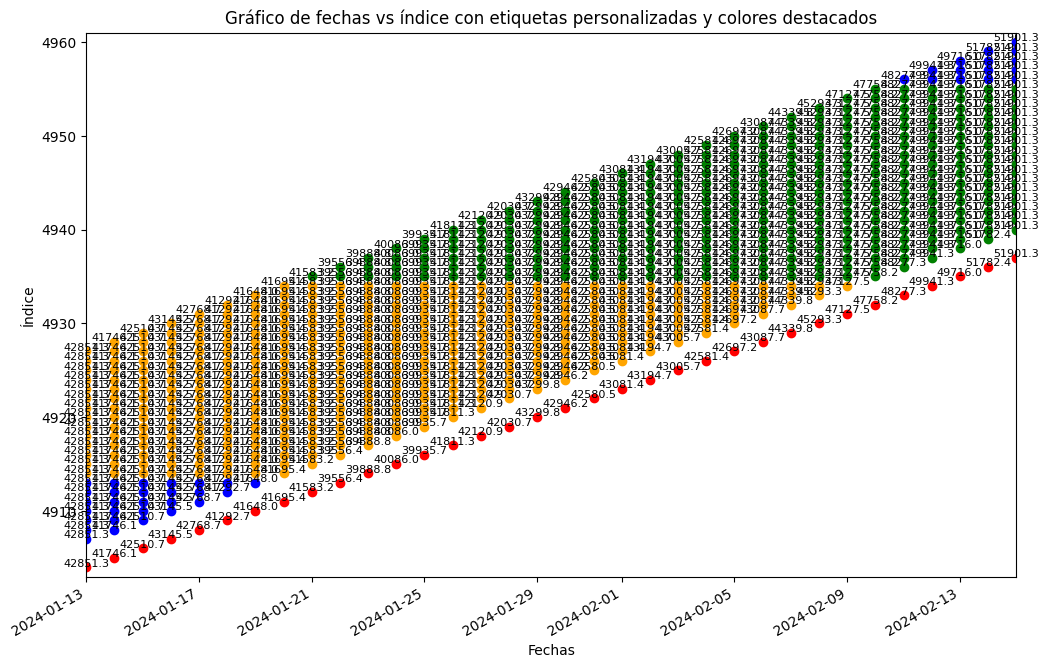


Window_21:
            0          1          2          3          4          5  \
0 2010-07-18 2010-07-19 2010-07-20 2010-07-21 2010-07-22 2010-07-23   
1 2010-07-19 2010-07-20 2010-07-21 2010-07-22 2010-07-23 2010-07-24   
2 2010-07-20 2010-07-21 2010-07-22 2010-07-23 2010-07-24 2010-07-25   
3 2010-07-21 2010-07-22 2010-07-23 2010-07-24 2010-07-25 2010-07-26   
4 2010-07-22 2010-07-23 2010-07-24 2010-07-25 2010-07-26 2010-07-27   

           6          7          8          9  ...         12         13  \
0 2010-07-24 2010-07-25 2010-07-26 2010-07-27  ... 2010-07-30 2010-07-31   
1 2010-07-25 2010-07-26 2010-07-27 2010-07-28  ... 2010-07-31 2010-08-01   
2 2010-07-26 2010-07-27 2010-07-28 2010-07-29  ... 2010-08-01 2010-08-02   
3 2010-07-27 2010-07-28 2010-07-29 2010-07-30  ... 2010-08-02 2010-08-03   
4 2010-07-28 2010-07-29 2010-07-30 2010-07-31  ... 2010-08-03 2010-08-04   

          14         15         16         17         18         19  \
0 2010-08-01 2010-08-02 2010-08-

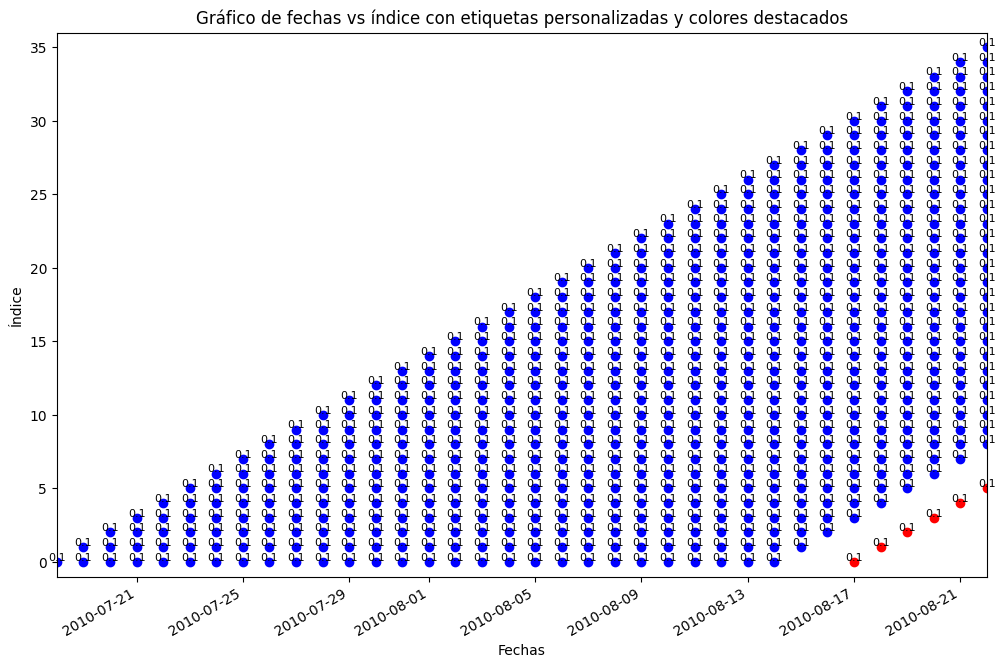

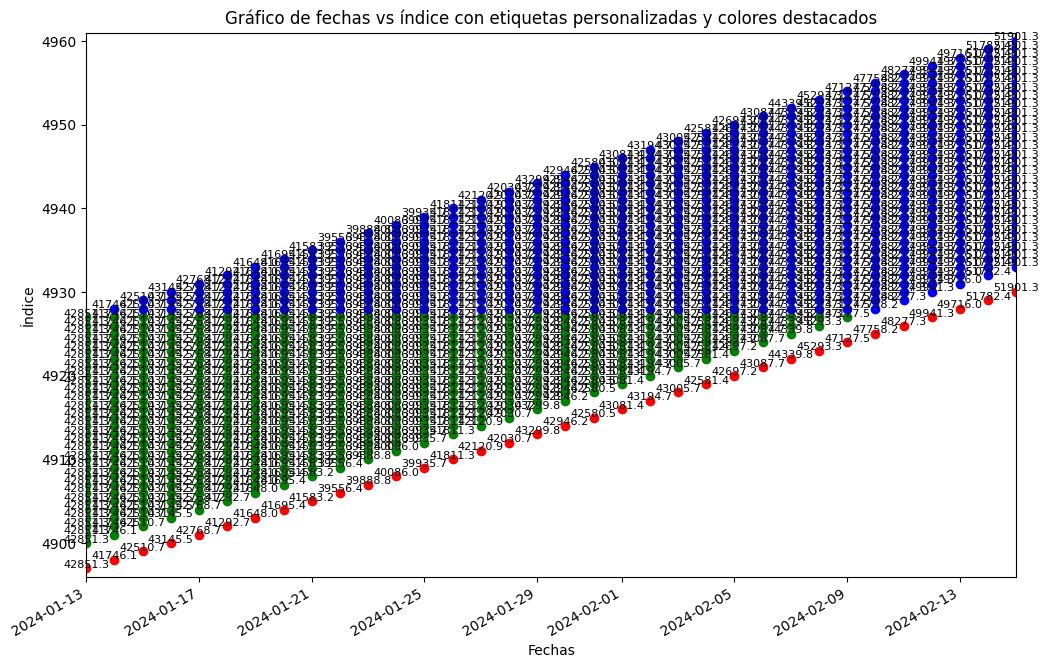


Window_28:
            0          1          2          3          4          5  \
0 2010-07-18 2010-07-19 2010-07-20 2010-07-21 2010-07-22 2010-07-23   
1 2010-07-19 2010-07-20 2010-07-21 2010-07-22 2010-07-23 2010-07-24   
2 2010-07-20 2010-07-21 2010-07-22 2010-07-23 2010-07-24 2010-07-25   
3 2010-07-21 2010-07-22 2010-07-23 2010-07-24 2010-07-25 2010-07-26   
4 2010-07-22 2010-07-23 2010-07-24 2010-07-25 2010-07-26 2010-07-27   

           6          7          8          9  ...         19         20  \
0 2010-07-24 2010-07-25 2010-07-26 2010-07-27  ... 2010-08-06 2010-08-07   
1 2010-07-25 2010-07-26 2010-07-27 2010-07-28  ... 2010-08-07 2010-08-08   
2 2010-07-26 2010-07-27 2010-07-28 2010-07-29  ... 2010-08-08 2010-08-09   
3 2010-07-27 2010-07-28 2010-07-29 2010-07-30  ... 2010-08-09 2010-08-10   
4 2010-07-28 2010-07-29 2010-07-30 2010-07-31  ... 2010-08-10 2010-08-11   

          21         22         23         24         25         26  \
0 2010-08-08 2010-08-09 2010-08-

In [458]:
import pandas as pd

# Supongamos que ya tienes definida tu función `create_sliding_windows` y `plot_ts`

window_sizes = [7, 14, 21, 28]
step_size = 1
taus = [3]  # Consideramos valores hasta `tau` de 4 periodos adelante

# Crear los resultados
result_dict1 = create_sliding_windows(df_price.index, window_sizes, step_size, taus)
result_dict2 = create_sliding_windows(df_price.values, window_sizes, step_size, taus)

# Mostrar los resultados para cada tamaño de ventana
for window_key1, df1 in result_dict1.items():
    for window_key2, df2 in result_dict2.items():
        # Comprobar si las formas de los DataFrames coinciden
        if df1.shape == df2.shape:
            data = df1  # Datos del primer conjunto
            label_data = df2  # Datos del segundo conjunto
            s_date = pd.to_datetime("2010-07-18")
            e_date = pd.to_datetime("2010-08-22")
           
            import re
            # Usar expresiones regulares para extraer el número
            numero = re.search(r'\d+', window_key2)
            # Verificar si se encontró un número y convertirlo a entero
            if numero:
                numero_extraido = int(numero.group())
                print(numero_extraido)
                
            tau = list(range(numero_extraido, max(window_sizes)*2))
           # Llamar a la función para graficar
            plot_ts(data, label_data, s_date, e_date, tau,w=numero_extraido)
            
            s_date = pd.to_datetime("2024-01-13")
            e_date = pd.to_datetime("2024-02-15")
            
            plot_ts(data,label_data,s_date,e_date,tau,w=numero_extraido)
            
            # Mostrar algunas filas como referencia
            print(f"\n{window_key1}:\n", df1.head())
